In [1]:
import collections as clt
import itertools as it
import functools as ft
import operator as op
import pathlib as P
import pickle
import warnings

In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.cm as cm

In [3]:
ns = ["cc", "mf", "bp"]
ontology_lst = ["cellular_component", "molecular_function", "biological_process"]

In [4]:
# ppsim_pth = P.Path("/data0/shaojiangyi/pprogo-flg-1/data/mmseq_sim_csr.npz")
# ppsim_mat = sp.load_npz(ppsim_pth)
ppsim_path = P.Path("/data0/shaojiangyi/pprogo-flg-1/data/esm1_pp_100.dat")
ppsim_df = pd.read_csv(ppsim_path, sep="\t", names=[0,1,2,3])

In [5]:
ppsim_mat = sp.csr_matrix((ppsim_df[3], (ppsim_df[0], ppsim_df[1])))

In [6]:
# ppsim_mat
ppsim_mat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12407300 stored elements and shape (124073, 124073)>

In [7]:
data_path = [f"/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/{x}_data.pkl"
             for x in ["train", "valid", "test"]]
prot_data = pd.concat([pd.read_pickle(x) for x in data_path], ignore_index=True)

In [8]:
# load go term data
count_ic_path = "/data0/shaojiangyi/pprogo-flg-1/data/data-netgo/term_counts_with_position-111.pkl"
term_count_ic = pd.read_pickle(count_ic_path)

In [9]:
prot_names = prot_data["proteins"].unique()

In [10]:
# load protein name
pname_path = "/data0/shaojiangyi/pprogo-flg-1/data/protein_name.txt"
with open(pname_path, "r") as f:
    prot_names = [x.strip() for x in f.readlines()]

In [11]:
# load go term list
root_path = P.Path("/data0/zhaojianxiang/data/")
curr_labels = []
for n in ns:
    label_path = root_path / n / "go_list.txt"
    with open(label_path, "r") as f:
        labels = f.read().splitlines()
    curr_labels.append(labels)

In [12]:
namespace_terms = dict(zip(ontology_lst, curr_labels))
nspace_ti = {k: {x: i for i, x in enumerate(v)}
             for k, v in namespace_terms.items()}

In [13]:
prep_labels = [namespace_terms[i] for i in ontology_lst]

In [14]:
# load weak protein go relations
# weak_pgo_path = P.Path("/data0/shaojiangyi/pprogo-flg-1/data/esm1_mmseqs_prot_go_sim_csr.npz")
weak_pgo_path = P.Path("/data0/shaojiangyi/pprogo-flg-1/data/esm1_pg_100.dat")
# weak_pgo_mat = sp.load_npz(weak_pgo_path)
# weak_pgo_mat = np.load(weak_pgo_path)
weak_pgo_df = pd.read_csv(weak_pgo_path, sep="\t", names=[0,1,2,3])
weak_pgo_mat = sp.csr_matrix((weak_pgo_df[3], (weak_pgo_df[0], weak_pgo_df[1])))

In [15]:
weak_pgo_mat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12407300 stored elements and shape (124073, 31544)>

In [16]:
def align_labels_sparse_optimized(predicted_results, o1, o2, fill_value=0.0):
    """
    Ultra-optimized version using scipy sparse matrix operations.
    """
    N = predicted_results.shape[0]
    M_old = len(o1)
    M_new = len(o2)
    
    # Convert to CSC format for efficient column operations
    if not sp.isspmatrix_csc(predicted_results):
        predicted_results = predicted_results.tocsc()
    
    # Create label mappings
    o1_label_to_idx = {label: idx for idx, label in enumerate(o1)}
    
    if fill_value == 0.0:
        # Use scipy's advanced indexing for maximum efficiency
        old_indices = []
        new_indices = []
        
        for new_idx, label in enumerate(o2):
            if label in o1_label_to_idx:
                old_idx = o1_label_to_idx[label]
                old_indices.append(old_idx)
                new_indices.append(new_idx)
        
        if old_indices:
            # Create permutation matrix for column reordering
            # This is more efficient than column-by-column copying
            old_indices = np.array(old_indices)
            new_indices = np.array(new_indices)
            
            # Extract relevant columns
            relevant_data = predicted_results[:, old_indices]
            
            # Build the result matrix using constructor
            row_ind, col_ind = relevant_data.nonzero()
            data = relevant_data.data
            
            # Map old column indices to new column indices
            col_mapping = np.zeros(len(old_indices), dtype=int)
            col_mapping[np.arange(len(old_indices))] = new_indices
            new_col_ind = col_mapping[col_ind]
            
            aligned_results = sp.csr_matrix(
                (data, (row_ind, new_col_ind)), 
                shape=(N, M_new), 
                dtype=predicted_results.dtype
            )
        else:
            aligned_results = sp.csr_matrix((N, M_new), dtype=predicted_results.dtype)
    
    else:
        # For non-zero fill_value, we need to be more careful
        # This case is inherently less efficient for sparse matrices
        warnings.warn("Non-zero fill_value is less efficient for sparse matrices")
        
        # Create dense matrix with fill_value
        aligned_dense = np.full((N, M_new), fill_value, dtype=predicted_results.dtype)
        
        # Fill existing data
        for new_idx, label in enumerate(o2):
            if label in o1_label_to_idx:
                old_idx = o1_label_to_idx[label]
                aligned_dense[:, new_idx] = predicted_results[:, old_idx].toarray().ravel()
        
        aligned_results = sp.csr_matrix(aligned_dense)
    
    return aligned_results

In [17]:
weak_pgo_mat = align_labels_sparse_optimized(
                            weak_pgo_mat, 
                            list(it.chain.from_iterable(prep_labels)),
                            list(it.chain.from_iterable(curr_labels)))

In [18]:
# # saving
# saving_path = "/data0/shaojiangyi/pprogo-flg-1/data/esm1_pg_aligned.npz"
# sp.save_npz(saving_path, weak_pgo_mat)
# saving_path = "/data0/shaojiangyi/pprogo-flg-1/data/esm1_pg_100_aligned.npz"
# sp.save_npz(saving_path, weak_pgo_mat)

In [19]:
weak_pgo_mat

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12400184 stored elements and shape (124073, 31315)>

In [20]:
term_lst = list(it.chain.from_iterable(curr_labels))

In [21]:
len(term_lst)

31315

In [22]:
len(prot_names)

124073

In [23]:
# convert the sparse matrix to dictionary, key is the protein idx, value is a list of go idx
row_indices, col_indices = weak_pgo_mat.nonzero()
# Group column indices by row index
prot_labels = clt.defaultdict(list)
for protein_idx, go_idx in zip(row_indices, col_indices):
    prot_labels[prot_names[protein_idx]].append(term_lst[go_idx])

In [24]:
# load protein-go label data
# root_path = P.Path("/data0/shaojiangyi/pprogo-flg-1/data")
# prot_labels = []
# for n in ns:
#     y_label = root_path / n / "label.pkl"
#     with open(y_label, "rb") as f:
#         labels = pickle.load(f)
#     tmp = clt.defaultdict(list)
#     for k, v in zip(labels["protein"], labels["go"]):
#         tmp[k].append(v)
#     prot_labels.append(tmp)

In [25]:
# # build a mapping from protein to its go terms
# prot_labels = ft.reduce(
#     op.or_, [clt.defaultdict(list, x) for x in prot_labels]
# )

In [26]:
# convert to pandas dataframe
prot_labels_df = pd.DataFrame({
    "proteins": list(prot_labels.keys()),
    "go_terms": [x for x in prot_labels.values()]
})

In [27]:
prot_labels_df

,proteins,go_terms
0,Q5BHH6,"[GO:0009522, GO:0043659, GO:0043657, GO:001658..."
1,Q5BGS1,"[GO:0030139, GO:0020022, GO:0005581, GO:012000..."
2,Q5BHC4,"[GO:1905202, GO:0032059, GO:0097575, GO:004822..."
3,C8VRD6,"[GO:1905368, GO:0016012, GO:0032807, GO:199043..."
4,Q5BG78,"[GO:0032991, GO:0033557, GO:0005638, GO:003090..."
...,...,...
124068,Q96DC8,"[GO:0044157, GO:0008999, GO:0030603, GO:000172..."
124069,Q9VAM6,"[GO:1902494, GO:0070557, GO:0005583, GO:004529..."
124070,Q9VNF9,"[GO:0070850, GO:0050105, GO:0036082, GO:001677..."
124071,Q9VT33,"[GO:0071001, GO:0042729, GO:1990674, GO:003532..."


In [28]:
# calculate the degree of each protein 
# the ppsim_mat is a sparse matrix where the score denote the mmseqs identity score
# when calculating the degree, all the scores are considered as 1

# copy a matrix where the scores are all 1
ppsim_mat_deg = ppsim_mat.copy()
ppsim_mat_deg.data = np.ones_like(ppsim_mat_deg.data)
# calculate the indegree of each protein
prot_deg = ppsim_mat_deg.sum(axis=0).A1

# create a dataframe with the protein names and their degrees
prot_deg_df = pd.DataFrame({
    "proteins": prot_names,
    "indegree": prot_deg
}).astype({"proteins": str, "indegree": int})

In [29]:
# calculate the IC (information content) based on the degree
# first get all the number of triangular edges in the matrix
num_prots = len(prot_names)
prot_deg_df["ic"] = np.log2(num_prots / prot_deg_df["indegree"])

In [30]:
prot_deg_df

,proteins,indegree,ic
0,Q5BHH6,73,10.731005
1,Q5BGS1,60,11.013939
2,Q5BHC4,59,11.038187
3,C8VRD6,60,11.013939
4,Q5BG78,83,10.545790
...,...,...,...
124068,Q96DC8,150,9.692011
124069,Q9VAM6,32,11.920830
124070,Q9VNF9,207,9.227343
124071,Q9VT33,55,11.139470


In [31]:
np.quantile(prot_deg_df["ic"], np.linspace(0, 1, 21, endpoint=False))

array([ 5.34104234,  9.35097407,  9.64470527,  9.81230522,  9.94354975,
       10.05046495, 10.13946996, 10.22038996, 10.29147305, 10.36624082,
       10.42897658, 10.49456492, 10.56327767, 10.63542745, 10.69201098,
       10.77108255, 10.85474048, 10.96663336, 11.06284868, 11.22038996,
       11.46139806])

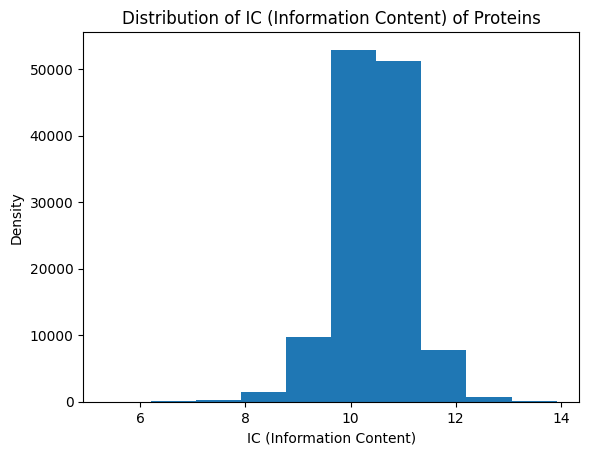

In [32]:
# simply show the distribution of IC protein
idx = prot_deg_df["ic"] != np.inf
plt.hist(prot_deg_df.loc[idx, "ic"])
plt.xlabel("IC (Information Content)")
plt.ylabel("Density")
plt.title("Distribution of IC (Information Content) of Proteins")
plt.show()

In [33]:
term_count = clt.Counter(it.chain.from_iterable(prot_labels.values()))

In [34]:
term_ic = {k: -np.log2(term_count[k] / len(prot_names))
           for k in term_count}

In [35]:
termic_dict = term_count_ic.set_index("gos")["ic"].to_dict()
protic_dict = prot_deg_df.set_index("proteins")["ic"].to_dict()

In [36]:
# for plotting, proteins, gos, p_ic, g_ic
prot_go_ic = clt.defaultdict(list)
for p, g in prot_labels.items():
    for go in g:
        prot_go_ic["proteins"].append(p)
        prot_go_ic["gos"].append(go)
        prot_go_ic["p_ic"].append(protic_dict[p])
        prot_go_ic["g_ic"].append(termic_dict[go])
prot_go_ic_df = pd.DataFrame(prot_go_ic) 

In [37]:
prot_go_ic_df

,proteins,gos,p_ic,g_ic
0,Q5BHH6,GO:0009522,10.731005,12.340893
1,Q5BHH6,GO:0043659,10.731005,16.340893
2,Q5BHH6,GO:0043657,10.731005,6.618086
3,Q5BHH6,GO:0016586,10.731005,10.817331
4,Q5BHH6,GO:0016006,10.731005,12.340893
...,...,...,...,...
12400179,Q9Z0V9,GO:0060922,11.248404,15.480585
12400180,Q9Z0V9,GO:0090579,11.248404,12.573695
12400181,Q9Z0V9,GO:0007319,11.248404,11.393122
12400182,Q9Z0V9,GO:0043436,11.248404,4.425642


Creating hexbin plots...
Creating plot for Shallow position...


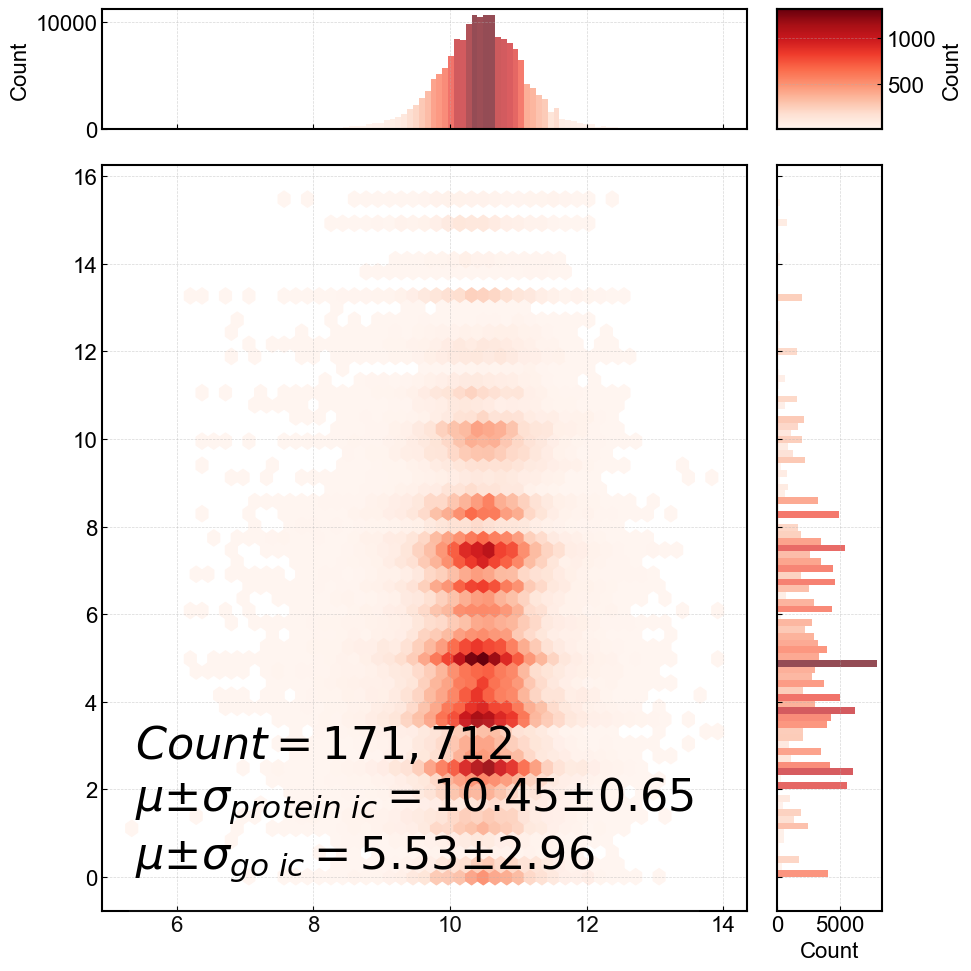

Creating plot for Medium position...


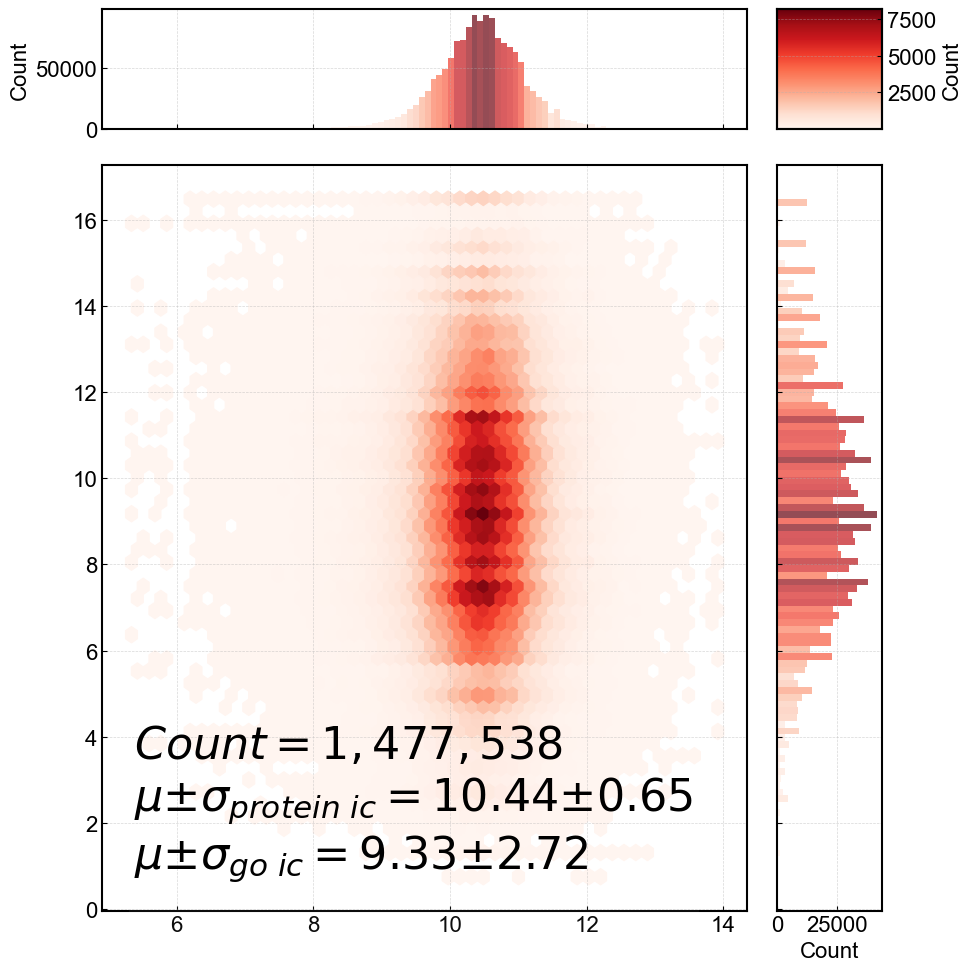

Creating plot for Deep position...


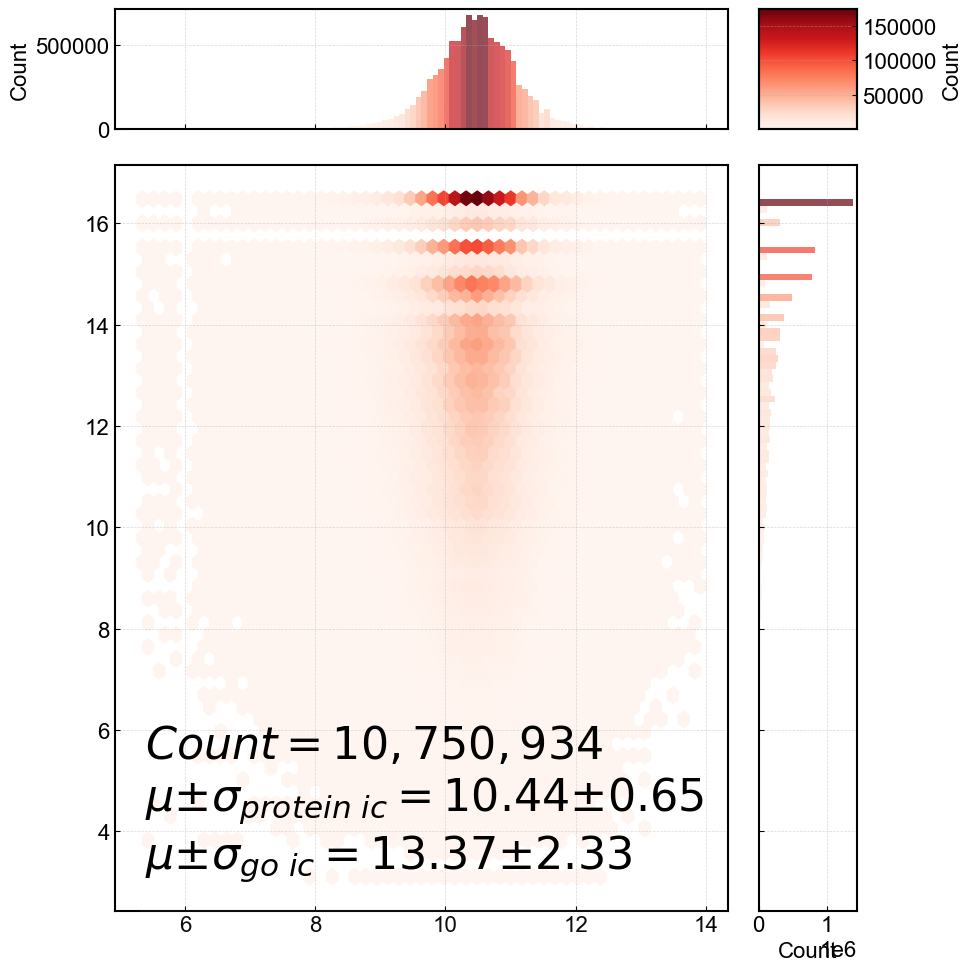

Creating plot for All position...


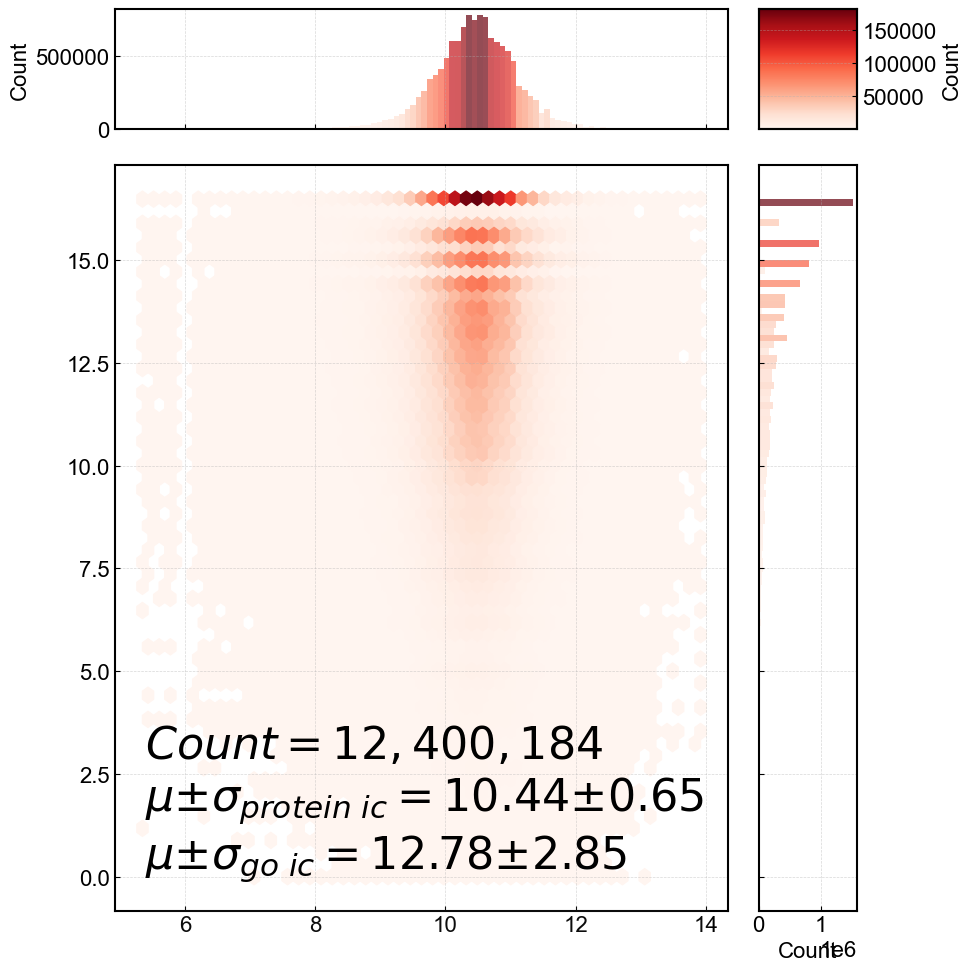

In [38]:
mpl.rcParams.update({
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 16
})

# Your existing data preparation code
prot_go_ic_df = prot_go_ic_df.replace([np.inf, -np.inf], np.nan).dropna()
merged_df = prot_go_ic_df.merge(term_count_ic[['gos', 'position']], on='gos', how='left')
positions = ['Shallow', 'Medium', 'Deep']
def create_hexbin_plot(data, title):
    """Create a hexbin plot with marginal histograms using colormap"""
    fig = plt.figure(figsize=(10, 10))
    n_sub = 6
    # Create main hexbin plot
    ax_main = plt.subplot2grid((n_sub, n_sub), (1, 0), colspan=n_sub-1, rowspan=n_sub-1)
    hb = ax_main.hexbin(data['p_ic'], data['g_ic'], gridsize=50, cmap='Reds', mincnt=1)
    # ax_main.set_xlabel('Protein IC')
    # ax_main.set_ylabel('GO IC')
    
    # Create marginal histograms with colormap
    ax_top = plt.subplot2grid((n_sub, n_sub), (0, 0), colspan=n_sub-1, sharex=ax_main)
    
    # Top histogram (p_ic) with colormap
    n_bins = 100
    counts_p, bins_p = np.histogram(data['p_ic'], bins=n_bins)
    bin_centers_p = (bins_p[:-1] + bins_p[1:]) / 2
    
    # Normalize counts for colormap
    norm_p = plt.Normalize(vmin=counts_p.min(), vmax=counts_p.max())
    colors_p = cm.Reds(norm_p(counts_p))
    
    ax_top.bar(bin_centers_p, counts_p, width=np.diff(bins_p), 
               color=colors_p, alpha=0.7, edgecolor='none')
    ax_top.set_ylabel('Count')
    ax_top.tick_params(labelbottom=False)
    
    # Right histogram (g_ic) with colormap
    ax_right = plt.subplot2grid((n_sub, n_sub), (1, n_sub-1), rowspan=n_sub-1, sharey=ax_main)
    
    counts_g, bins_g = np.histogram(data['g_ic'], bins=n_bins)
    bin_centers_g = (bins_g[:-1] + bins_g[1:]) / 2
    
    # Normalize counts for colormap
    norm_g = plt.Normalize(vmin=counts_g.min(), vmax=counts_g.max())
    colors_g = cm.Reds(norm_g(counts_g))
    
    ax_right.barh(bin_centers_g, counts_g, height=np.diff(bins_g),
                  color=colors_g, alpha=0.7, edgecolor='none')
    ax_right.set_xlabel('Count')
    ax_right.tick_params(labelleft=False)
    
    # Add colorbar
    cbar_ax = plt.subplot2grid((n_sub, n_sub), (0, n_sub-1))
    plt.colorbar(hb, cax=cbar_ax, label='Count')
    
    # plt.suptitle(f'{title} (n={len(data):,})')
    plt.tight_layout()
    
    return fig
# Create hexbin plots for each position
print("Creating hexbin plots...")
for position in positions + ['All']:
    if position == 'All':
        data = merged_df
    else:
        data = merged_df[merged_df['position'] == position]
    
    if len(data) == 0:
        print(f"No data for {position} position")
        continue
    
    print(f"Creating plot for {position} position...")
    fig = create_hexbin_plot(data, f'{position} Position')

    # set boarders and grid
    axs = fig.get_axes()
    for ax in axs:
        # set to black and increase the width
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1.5)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_facecolor('white')
    
    # display the statistics on the plot  
       
    # Add statistics text to the plot
    # add italics to the text
    stats_text = (
        f"$ Count = {len(data):,} $\n"
        # f"$ Protein\ IC: [{data['p_ic'].min():.3f}, {data['p_ic'].max():.3f}] $\n"
        # f"$ GO\ IC: [{data['g_ic'].min():.3f}, {data['g_ic'].max():.3f}] $\n"
        f"$ \mu ± \sigma_{{protein\ ic}} = {data['p_ic'].mean():.2f} ± {data['p_ic'].std():.2f} $\n"
        f"$ \mu ± \sigma_{{go\ ic}} = {data['g_ic'].mean():.2f} ± {data['g_ic'].std():.2f} $\n"
        # f"$ Corr = {data['p_ic'].corr(data['g_ic'], method='spearman'):.3f} $"
    )
    # Get the main hexbin plot axis
    ax_main = axs[0]  # Main plot is the second axes object
    
    # Add text box in top right corner of main plot
    ax_main.text(0.05, 0.25, stats_text,
                transform=ax_main.transAxes,
                verticalalignment='top',
                horizontalalignment='left',
                bbox=dict(facecolor='white', alpha=0.05, edgecolor='none'),
                fontdict={'fontsize': 32},
                )

    plt.show()

    # saving plotting figures
    saving_root = P.Path("/data0/shaojiangyi/pprogo-flg-1/notebooks/perf_analysis/figures")
    file_name = "weak_prot_go_ic_hexbin_1"
    saving_path = saving_root / f"{file_name}_{position}"
    fig.savefig(f"{saving_path}.svg", bbox_inches='tight')
    fig.savefig(f"{saving_path}.png", bbox_inches='tight', dpi=300)


# # Print summary statistics
# print("\nSummary Statistics:")
# print("=" * 50)